In [ ]:
!pip install torch_geometric

In [2]:
!git clone https://github.com/faranbutt/brain-age-gnn-oasis3.git

Cloning into 'brain-age-gnn-oasis3'...
remote: Enumerating objects: 1730, done.
remote: Counting objects: 100% (261/261), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 1730 (delta 131), reused 158 (delta 94), pack-reused 1469 (from 2)
Receiving objects: 100% (1730/1730), 2.40 MiB | 2.48 MiB/s, done.
Resolving deltas: 100% (610/610), done.


In [3]:
import time
import os
import copy
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, SAGEConv, GATv2Conv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import platform
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from torch_geometric.utils import to_undirected, dense_to_sparse

In [4]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
print(f"Pytorch Version  = {torch.__version__}")
print(f"OS  = {platform.system()} {platform.release()}")
print(f"Processor = {platform.processor()}")

Pytorch Version  = 2.10.0+cu128
OS  = Linux 6.6.113+
Processor = x86_64


In [7]:
START_TIME = time.time()
START_TIME

1774467038.656877

In [8]:
train_df = pd.read_csv("/content/brain-age-gnn-oasis3/data/public/train_data.csv")
train_df.head()

,Subject,MR_session,age at visit,ctx-lh-bankssts_volume,ctx-lh-bankssts_thickness,ctx-lh-caudalanteriorcingulate_volume,ctx-lh-caudalanteriorcingulate_thickness,ctx-lh-caudalmiddlefrontal_volume,ctx-lh-caudalmiddlefrontal_thickness,ctx-lh-cuneus_volume,...,ctx-rh-superiorparietal_volume,ctx-rh-superiorparietal_thickness,ctx-rh-superiortemporal_volume,ctx-rh-superiortemporal_thickness,ctx-rh-supramarginal_volume,ctx-rh-supramarginal_thickness,ctx-rh-temporalpole_volume,ctx-rh-temporalpole_thickness,ctx-rh-transversetemporal_volume,ctx-rh-transversetemporal_thickness
0,OAS30001,OAS30001_MR_d0757,67.262553,1773,2.449,1695,2.694,3727,2.350,2152,...,10349,2.183,8603,2.630,6087,2.243,2168,3.706,647,2.299
1,OAS30001,OAS30001_MR_d3132,73.764949,1699,2.342,1799,3.053,3715,2.371,2244,...,10903,2.175,8928,2.698,6622,2.369,1965,3.612,578,2.313
2,OAS30003,OAS30003_MR_d1631,63.275435,2145,2.297,1931,2.942,5993,2.537,2359,...,12530,2.168,10591,2.621,10968,2.486,2092,3.955,941,2.650
3,OAS30003,OAS30003_MR_d2669,66.117324,1853,2.166,1905,3.089,5571,2.481,2134,...,12591,2.172,10740,2.604,10520,2.411,1966,3.616,904,2.450
4,OAS30004,OAS30004_MR_d1101,58.144374,2225,2.387,1790,2.595,6348,2.316,2994,...,13325,2.172,11885,2.688,9572,2.431,2297,3.620,985,2.102


In [9]:
val_df = pd.read_csv('/content/brain-age-gnn-oasis3/data/public/val_data.csv')
val_df.head()

,Subject,MR_session,age at visit,ctx-lh-bankssts_volume,ctx-lh-bankssts_thickness,ctx-lh-caudalanteriorcingulate_volume,ctx-lh-caudalanteriorcingulate_thickness,ctx-lh-caudalmiddlefrontal_volume,ctx-lh-caudalmiddlefrontal_thickness,ctx-lh-cuneus_volume,...,ctx-rh-superiorparietal_volume,ctx-rh-superiorparietal_thickness,ctx-rh-superiortemporal_volume,ctx-rh-superiortemporal_thickness,ctx-rh-supramarginal_volume,ctx-rh-supramarginal_thickness,ctx-rh-temporalpole_volume,ctx-rh-temporalpole_thickness,ctx-rh-transversetemporal_volume,ctx-rh-transversetemporal_thickness
0,OAS30006,OAS30006_MR_d0373,63.151218,1944,2.257,3151,2.372,8651,2.486,2276,...,14909,2.105,11973,2.529,9888,2.278,2755,3.707,1012,2.235
1,OAS30006,OAS30006_MR_d2341,68.539309,1858,2.111,2672,2.337,7534,2.187,1987,...,14822,2.107,10458,2.343,8840,2.183,2906,3.321,979,2.260
2,OAS30088,OAS30088_MR_d0093,76.274620,2096,2.430,1469,2.534,4523,2.296,2714,...,10847,2.147,8636,2.485,7909,2.225,1804,3.946,661,2.497
3,OAS30090,OAS30090_MR_d0118,53.083066,2958,2.778,1956,2.562,5950,2.616,3387,...,13490,2.191,12306,2.993,11623,2.566,2580,4.235,821,2.586
4,OAS30127,OAS30127_MR_d0098,65.808309,2197,2.292,1595,2.722,5157,2.225,2817,...,11485,1.964,11929,2.576,9910,2.329,2360,3.569,935,2.023


In [10]:
test_df = pd.read_csv('/content/brain-age-gnn-oasis3/data/public/test_data.csv')
test_df.head()

,Subject,MR_session,ctx-lh-bankssts_volume,ctx-lh-bankssts_thickness,ctx-lh-caudalanteriorcingulate_volume,ctx-lh-caudalanteriorcingulate_thickness,ctx-lh-caudalmiddlefrontal_volume,ctx-lh-caudalmiddlefrontal_thickness,ctx-lh-cuneus_volume,ctx-lh-cuneus_thickness,...,ctx-rh-superiorparietal_volume,ctx-rh-superiorparietal_thickness,ctx-rh-superiortemporal_volume,ctx-rh-superiortemporal_thickness,ctx-rh-supramarginal_volume,ctx-rh-supramarginal_thickness,ctx-rh-temporalpole_volume,ctx-rh-temporalpole_thickness,ctx-rh-transversetemporal_volume,ctx-rh-transversetemporal_thickness
0,Test_Sub_001,Sess_01,1830,2.285,1468,3.028,6074,2.419,2827,1.769,...,10811,2.122,11621,2.659,9876,2.487,2694,4.128,763,2.103
1,Test_Sub_001,Sess_02,1905,2.275,1399,2.977,6280,2.453,2706,1.772,...,11121,2.108,11442,2.638,9795,2.463,2634,3.952,742,1.996
2,Test_Sub_002,Sess_01,3118,2.468,2193,2.725,6249,2.481,2778,2.079,...,14822,2.328,12271,2.782,10334,2.540,1939,3.610,1203,2.532
3,Test_Sub_002,Sess_02,2952,2.419,2020,2.689,5998,2.491,2921,1.975,...,14227,2.258,12049,2.722,10177,2.430,1974,3.628,1077,2.231
4,Test_Sub_003,Sess_01,2618,2.606,2563,2.543,5300,2.516,2734,1.608,...,14451,2.095,10480,2.706,9112,2.435,2440,3.931,845,2.520


In [11]:
adjancey_matrix_of_OAS30001_d0757_df = pd.read_csv('/content/brain-age-gnn-oasis3/data/public/adjacency_matrices/OAS30001_d0757.csv')
adjancey_matrix_of_OAS30001_d0757_df

,Unnamed: 0,ctx-lh-bankssts,ctx-lh-caudalanteriorcingulate,ctx-lh-caudalmiddlefrontal,ctx-lh-cuneus,ctx-lh-entorhinal,ctx-lh-frontalpole,ctx-lh-fusiform,ctx-lh-inferiorparietal,ctx-lh-inferiortemporal,...,ctx-rh-precentral,ctx-rh-precuneus,ctx-rh-rostralanteriorcingulate,ctx-rh-rostralmiddlefrontal,ctx-rh-superiorfrontal,ctx-rh-superiorparietal,ctx-rh-superiortemporal,ctx-rh-supramarginal,ctx-rh-temporalpole,ctx-rh-transversetemporal
0,ctx-lh-bankssts,497.0,0.0,0.0,1.0,4.0,0.0,109.0,362.0,167.0,...,0.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,ctx-lh-caudalanteriorcingulate,0.0,562.0,61.0,0.0,0.0,0.0,0.0,1.0,0.0,...,24.0,5.0,36.0,56.0,230.0,2.0,0.0,3.0,0.0,0.0
2,ctx-lh-caudalmiddlefrontal,0.0,61.0,2309.0,0.0,0.0,0.0,0.0,1.0,0.0,...,14.0,4.0,0.0,1.0,46.0,1.0,1.0,0.0,0.0,0.0
3,ctx-lh-cuneus,1.0,0.0,0.0,1155.0,0.0,0.0,20.0,55.0,2.0,...,0.0,16.0,0.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0
4,ctx-lh-entorhinal,4.0,0.0,0.0,0.0,432.0,0.0,431.0,2.0,120.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,ctx-rh-superiorparietal,0.0,2.0,1.0,5.0,0.0,0.0,2.0,23.0,1.0,...,158.0,2196.0,0.0,1.0,7.0,5251.0,31.0,260.0,0.0,9.0
64,ctx-rh-superiortemporal,1.0,0.0,1.0,1.0,0.0,0.0,0.0,5.0,1.0,...,24.0,45.0,0.0,0.0,3.0,31.0,4298.0,303.0,96.0,583.0
65,ctx-rh-supramarginal,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,334.0,51.0,0.0,5.0,13.0,260.0,303.0,3709.0,0.0,23.0
66,ctx-rh-temporalpole,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,96.0,0.0,317.0,0.0


In [12]:
all_df = pd.concat([train_df,val_df],ignore_index=True)

In [13]:
print(f"Train Samples = {train_df.shape}")
print(f"Val Samples = {val_df.shape}")
print(f"Test Samples = {test_df.shape}")
print(f"All Df = {all_df.shape}")

Train Samples = (353, 139)
Val Samples = (39, 139)
Test Samples = (39, 138)
All Df = (392, 139)


Text(0.5, 1.0, 'Age Boxplot')

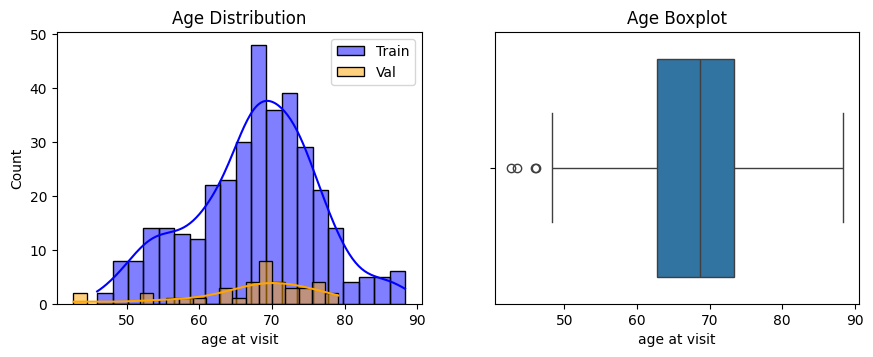

In [14]:
fig = plt.figure(figsize = (16,12))
ax1  = plt.subplot(3,3,1)
sns.histplot(train_df['age at visit'],bins=20,kde=True,label="Train",color='blue',alpha=0.5)
sns.histplot(val_df['age at visit'],bins=20,kde=True,label="Val",color='orange',alpha=0.5)
ax1.set_title("Age Distribution")
ax1.legend()


ax2 = plt.subplot(3,3,2)
sns.boxplot(data=all_df,x = 'age at visit')
ax2.set_title('Age Boxplot')


In [15]:
feat_cols = [c for c in train_df.columns if 'volume' in c or 'thickness' in c]
print(f'Nume of raw features  = {len(feat_cols)}')

Nume of raw features  = 136


In [16]:
def region_stats(df):
  X = df[feat_cols].values.astype(np.float32)
  X = X.reshape(-1,68,2)
  mean_vol = X[:,:,0].mean(axis = 0)
  std_vol = X[:,:,0].std(axis=0)
  mean_th = X[:,:,1].mean(axis=0)
  std_th = X[:,:,1].std(axis=0)
  return mean_vol,std_vol,mean_th,std_th

In [17]:
train_mean_vol, train_std_vol, train_mean_th, train_std_th = region_stats(train_df)
val_mean_vol, val_std_vol, val_mean_th, val_std_th = region_stats(val_df)

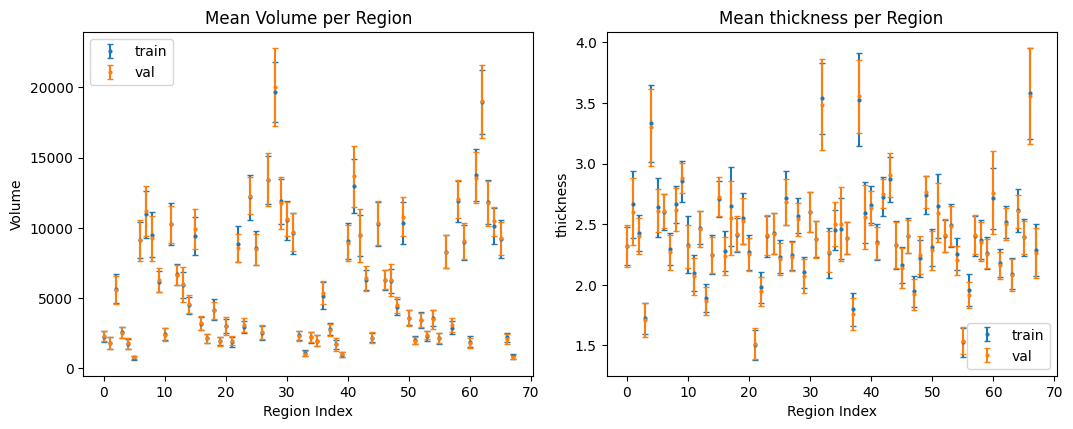

In [18]:
fig = plt.figure(figsize = (16,12))
ax1 = plt.subplot(3,3,1)
ax1.errorbar(range(68),train_mean_vol, yerr=train_std_vol,fmt='o',markersize=2,capsize=2,label='train')
ax1.errorbar(range(68),val_mean_vol, yerr=val_std_vol, fmt='o',markersize=2,capsize=2,label="val")
ax1.set_title('Mean Volume per Region')
ax1.set_xlabel("Region Index")
ax1.set_ylabel("Volume")
ax1.legend()

ax2 = plt.subplot(3,3,2)
ax2.errorbar(range(68),train_mean_th, yerr=train_std_th,fmt='o',markersize=2,capsize=2,label='train')
ax2.errorbar(range(68),val_mean_th, yerr=val_std_th, fmt='o',markersize=2,capsize=2,label="val")
ax2.set_title('Mean thickness per Region')
ax2.set_xlabel("Region Index")
ax2.set_ylabel("thickness")
ax2.legend()

plt.tight_layout()
plt.show()


In [19]:
row1 = train_df.iloc[0]
sub = row1['Subject']
sess = row1['MR_session']
sess = sess.replace(f"{sub}_MR_","")
adj_dir = '/content/brain-age-gnn-oasis3/data/public/adjacency_matrices'
adj_path = os.path.join(adj_dir,f'{sub}_{sess}.csv')
adj = pd.read_csv(adj_path,index_col=0).values.astype(np.float32)
G = nx.Graph()
n_nodes = adj.shape[0]
G.add_nodes_from(range(n_nodes))
for i in range(n_nodes):
  for j in range(i+1,n_nodes):
    if adj[i,j] >0:
      G.add_edge(i,j,weight=adj[i,j])

In [20]:
degrees = [d for n,d in G.degree()]
w_d = [sum(adj[i]) for i in range(n_nodes)]

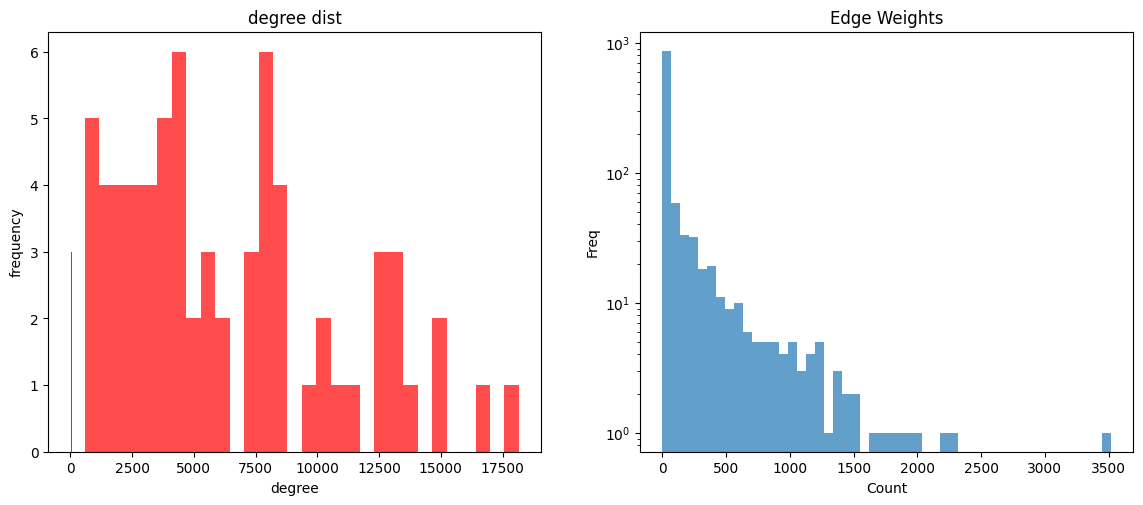

In [21]:
fig = plt.figure(figsize=(14, 12))
ax1 = plt.subplot(2,2,1)
ax1.hist(degrees,bins=30,alpha=0.7,label="unwighted",color='blue')
ax1.hist(w_d,bins=30,alpha=0.7,label='weighted',color='red')
ax1.set_title('degree dist')
ax1.set_xlabel('degree')
ax1.set_ylabel('frequency')

weights = [d['weight'] for (u,v,d) in G.edges(data=True)]
ax2 = plt.subplot(2,2,2)
ax2.hist(weights,bins=50,log=True,alpha=0.7)
ax2.set_title("Edge Weights")
ax2.set_xlabel('Count')
ax2.set_ylabel('Freq')
plt.show()

In [22]:
density = nx.density(G)
n_comp = nx.number_connected_components(G)
largest_comp = max(nx.connected_components(G),key=len)
largest_comp_size = len(largest_comp)

print(f"Largest Com = {largest_comp_size}")

Largest Com = 68


In [23]:
clustering = nx.average_clustering(G,weight='weight')
mean_deg = np.mean(degrees)
print(f"num of nodes = {G.number_of_nodes()}")
print(f"Num of edges = {G.number_of_edges()}")
print(f"Graph density=  {density}")
print(f"Num of connected components = {n_comp}")
print(f"Avergae clustering = {clustering:.4f}")
print(f'Average degree ={mean_deg}')
print(f'Avg weighted degree = {np.mean(w_d)}')

num of nodes = 68
Num of edges = 1116
Graph density=  0.48990342405618964
Num of connected components = 1
Avergae clustering = 0.0097
Average degree =32.8235294117647
Avg weighted degree = 6433.11767578125


In [24]:
print(f"TRain Mean node faeture values over all features = {train_df[feat_cols].values.astype(np.float32).mean(axis=0).mean()}")
print(f"Val Mean node faeture values over all features = {val_df[feat_cols].values.astype(np.float32).mean(axis=0).mean()}")
print(f"Test node faeture values over all features = {test_df[feat_cols].values.astype(np.float32).mean(axis=0).mean()}")


TRain Mean node faeture values over all features = 3081.3486328125
Val Mean node faeture values over all features = 3104.139404296875
Test node faeture values over all features = 3096.056884765625


In [25]:
X_train = train_df[feat_cols].values.astype(np.float32).reshape(-1,68,2)
X_test = test_df[feat_cols].values.astype(np.float32).reshape(-1,68,2)
X_val = val_df[feat_cols].values.astype(np.float32).reshape(-1,68,2)

In [26]:
scaler = StandardScaler()

train_flat = X_train.reshape(-1,2)
scaler.fit(train_flat)

StandardScaler()

In [27]:
X_train_s = scaler.transform(train_flat).reshape(X_train.shape)
X_val_s = scaler.transform(X_val.reshape(-1, 2)).reshape(X_val.shape)
X_test_s = scaler.transform(X_test.reshape(-1, 2)).reshape(X_test.shape)

In [28]:
y_train = train_df['age at visit'].values.astype(np.float32)
y_val = val_df['age at visit'].values.astype(np.float32)

In [29]:
def load_adj(sub,sess,is_test):
  if is_test:
    fname = f'{sub}-{sess}.csv'
  else:
    sess = sess.replace(f'{sub}_MR_',"")
    fname = f'{sub}_{sess}.csv'
  path = os.path.join(adj_dir,fname)
  adj = pd.read_csv(path,index_col=0).values.astype(np.float32)
  adj_t = torch.tensor(adj,dtype=torch.float)
  edge_idx, edge_attr = (dense_to_sparse(adj_t))
  return edge_idx, edge_attr

In [30]:
def make_data(df,X_scaled,y=None,is_test=False):
  data_list = []
  for idx,row in df.iterrows():
    sub = row["Subject"]
    sess = row["MR_session"]
    x = torch.tensor(X_scaled[idx],dtype=torch.float)
    edge_index,edge_attr = load_adj(sub,sess,is_test=is_test)
    if y is not None:
      target = torch.tensor([y[idx]],dtype=torch.float)
    else:
      target = torch.tensor([0.0],dtype=torch.float)
    data = Data(x=x,edge_index=edge_index,edge_attr=edge_attr,y=target)
    data_list.append(data)
  return data_list

In [31]:
train_data_list = make_data(train_df,X_train_s,y_train,is_test=False)
val_data_list = make_data(val_df,X_val_s,y_val,is_test=False)
test_data_list = make_data(test_df,X_test_s,is_test=True)

In [32]:
train_loader = DataLoader(train_data_list,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data_list,batch_size=32,shuffle=False)
test_loader = DataLoader(test_data_list,batch_size=32,shuffle=False)

In [33]:
class GCN(nn.Module):
  def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
      super().__init__()
      self.dropout = dropout
      self.convs = nn.ModuleList()
      self.bns = nn.ModuleList()
      self.convs.append(GCNConv(in_channels, hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))

      for i in range(num_layers - 1):
          self.convs.append(GCNConv(hidden_channels, hidden_channels))
          self.bns.append(nn.BatchNorm1d(hidden_channels))

      self.reg = nn.Sequential(
          nn.Linear(hidden_channels, hidden_channels // 2),
          nn.ReLU(),
          nn.Dropout(dropout),
          nn.Linear(hidden_channels // 2, out_channels)
      )

  def forward(self, data):
      x, edge_index, edge_weight,batch = data.x, data.edge_index, data.edge_attr,data.batch
      for i, conv in enumerate(self.convs):
          x = conv(x, edge_index, edge_weight=edge_weight)
          x = self.bns[i](x)
          x = F.relu(x)
          x = F.dropout(x, p=self.dropout, training=self.training)
      x = global_mean_pool(x,batch)
      return self.reg(x).squeeze(-1)

In [34]:
class GraphSage(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_channels, hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))

    for i in range(num_layers-1):
      self.convs.append(SAGEConv(hidden_channels, hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))

    self.reg = nn.Sequential(
        nn.Linear(hidden_channels, hidden_channels // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels // 2, out_channels)
    )

  def forward(self,data):
    x, edge_index, edge_weight,batch = data.x, data.edge_index, data.edge_attr,data.batch
    for i, conv in enumerate(self.convs):
          x = conv(x, edge_index)
          x = self.bns[i](x)
          x = F.relu(x)
          x = F.dropout(x, p=self.dropout, training=self.training)
    x = global_mean_pool(x,batch)
    return self.reg(x).squeeze(-1)


In [35]:
class GAT(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,heads,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs= nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GATv2Conv(in_channels,hidden_channels,heads=heads,concat=True,dropout=dropout))
    self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
    for i in range(num_layers-2):
      self.convs.append(GATv2Conv(hidden_channels * heads,hidden_channels,heads=heads,concat=True,dropout=dropout))
      self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
    if num_layers > 1:
      self.convs.append(GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout))
      final_dim = hidden_channels
    else:
      self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=1, concat=False, dropout=dropout))
      final_dim = hidden_channels

    self.reg = nn.Sequential(
        nn.Linear(final_dim,final_dim // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(final_dim // 2, out_channels)
    )
  def forward(self,data):
    x, edge_index, batch = data.x, data.edge_index, data.batch
    for i, conv in enumerate(self.convs):
        x = conv(x, edge_index)
        if i < len(self.bns):
            x = self.bns[i](x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
    x = global_mean_pool(x, batch)
    return self.reg(x).squeeze(-1)


In [36]:
def train(model,loader,optimizer,criterion):
  model.train()
  total_loss=  0
  for data in loader:
    data = data.to(device)
    optimizer.zero_grad()
    out = model(data)
    loss=  criterion(out,data.y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * data.num_graphs
  return total_loss / len(loader.dataset)

In [37]:
@torch.no_grad()
def eval(model,loader,criterion):
  model.eval()
  total_loss = 0
  for data in loader:
    data = data.to(device)
    out = model(data)
    loss=  criterion(out,data.y)
    total_loss += loss.item() * data.num_graphs
  return total_loss / len(loader.dataset)

In [38]:
def train_model(model,train_loader,val_loader,epochs,lr,weight_decay,patience):
  model = model.to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-5)
  criterion = nn.L1Loss()

  best_val_loss = float('inf')
  best_state = None
  patience_ctr = 0
  history = {'train_loss':[],'val_loss':[]}
  start_time = time.time()
  for epoch in range(1,epochs+1):
    train_loss = train(model,train_loader,optimizer,criterion)
    val_loss = eval(model,val_loader,criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr = 0
    else:
      patience_ctr+=1
      if patience_ctr >= patience:
        print(f"early stopping at {epoch}")
        break
    if epoch % 10 == 0:
      print(f"Epoch {epoch:3d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f}")
  elapsed = time.time() - start_time
  model.load_state_dict(best_state)
  return model,best_val_loss,history,elapsed

In [67]:
hp_results = []
run_id = 0

In [68]:
print("GCN Training")
gcn = GCN(in_channels=2,hidden_channels=64,out_channels=1,num_layers=4,dropout=0.5)
best_gcn_model,best_val_gcn,hist_gcn,t_gcn = train_model(gcn,train_loader,val_loader,epochs=300,lr=0.008,weight_decay=5e-4,patience=40)
hp_results.append({
    'run':run_id+1,
    'arch': 'GCN',
    'hidden': 64,
    'layers': 2,
    'val_mae': best_val_gcn,
    'time_sec': t_gcn
    })
run_id += 1

GCN Training
Epoch  10 | Train MAE: 13.5100 | Val MAE: 6.4313
Epoch  20 | Train MAE: 13.6629 | Val MAE: 7.8634
Epoch  30 | Train MAE: 14.8587 | Val MAE: 6.0874
Epoch  40 | Train MAE: 13.6933 | Val MAE: 6.8613
Epoch  50 | Train MAE: 14.5551 | Val MAE: 8.3332
Epoch  60 | Train MAE: 14.6223 | Val MAE: 6.9003
Epoch  70 | Train MAE: 13.5423 | Val MAE: 7.0034
Epoch  80 | Train MAE: 14.1842 | Val MAE: 6.5214
Epoch  90 | Train MAE: 14.5074 | Val MAE: 7.4517
Epoch 100 | Train MAE: 13.2521 | Val MAE: 6.1321
early stopping at 105


In [69]:
print("GraphSage Training")
gcn = GraphSage(in_channels=2,hidden_channels=64,out_channels=1,num_layers=2,dropout=0.5)
best_sage_model,best_val_sage,hist_sage,t_sage = train_model(gcn,train_loader,val_loader,epochs=300,lr=0.008,weight_decay=5e-4,patience=40)
hp_results.append({
    'run':run_id+1,
    'arch': 'GraphSage',
    'hidden': 64,
    'layers': 2,
    'val_mae': best_val_sage,
    'time_sec': t_sage
    })
run_id += 1

GraphSage Training
Epoch  10 | Train MAE: 14.3181 | Val MAE: 9.1235
Epoch  20 | Train MAE: 13.2612 | Val MAE: 7.1861
Epoch  30 | Train MAE: 14.4222 | Val MAE: 7.0956
Epoch  40 | Train MAE: 13.8456 | Val MAE: 6.4200
Epoch  50 | Train MAE: 14.4759 | Val MAE: 7.5584
early stopping at 54


In [70]:
print("GAT Training")
gat = GAT(in_channels=2, hidden_channels=32, out_channels=1, heads=2, num_layers=2, dropout=0.9)
best_gat_model, best_val_gat, hist_gat, t_gat = train_model(gat, train_loader, val_loader, epochs=300, lr=0.005, weight_decay=5e-4, patience=40)
hp_results.append({
    'run': run_id+1,
    'arch': 'GAT',
    'hidden': 64,
    'layers': 2,
    'heads': 4,
    'val_mae': best_val_gat,
    'time_sec': t_gat
})
run_id += 1

GAT Training
Epoch  10 | Train MAE: 43.9513 | Val MAE: 58.0025
Epoch  20 | Train MAE: 43.0867 | Val MAE: 53.7257
Epoch  30 | Train MAE: 44.1684 | Val MAE: 53.2924
Epoch  40 | Train MAE: 41.3085 | Val MAE: 49.3040
Epoch  50 | Train MAE: 38.1031 | Val MAE: 44.7602
Epoch  60 | Train MAE: 39.3470 | Val MAE: 44.7610
Epoch  70 | Train MAE: 41.1305 | Val MAE: 43.3102
Epoch  80 | Train MAE: 40.2301 | Val MAE: 41.1677
Epoch  90 | Train MAE: 38.5269 | Val MAE: 37.0699
Epoch 100 | Train MAE: 38.7258 | Val MAE: 34.4750
Epoch 110 | Train MAE: 38.3362 | Val MAE: 32.3803
Epoch 120 | Train MAE: 36.5236 | Val MAE: 30.8610
Epoch 130 | Train MAE: 35.4622 | Val MAE: 30.9650
Epoch 140 | Train MAE: 34.1370 | Val MAE: 28.4013
Epoch 150 | Train MAE: 35.4860 | Val MAE: 30.7309
Epoch 160 | Train MAE: 37.0835 | Val MAE: 28.0875
Epoch 170 | Train MAE: 35.3273 | Val MAE: 28.2494
Epoch 180 | Train MAE: 36.5448 | Val MAE: 28.4819
Epoch 190 | Train MAE: 34.1832 | Val MAE: 28.0417
Epoch 200 | Train MAE: 33.2608 | Val 

In [72]:
hp_df = pd.DataFrame(hp_results)
hp_df

,run,arch,hidden,layers,val_mae,time_sec,heads
0,1,GCN,64,2,5.838286,19.424359,NaN
1,2,GraphSage,64,2,5.586001,4.905555,NaN
2,3,GAT,64,2,25.697621,37.564016,4.0


In [81]:
torch.save(best_sage_model.state_dict(),'best_sage_model.pt')

In [77]:
best_sage_model.eval()
test_preds = []
with torch.no_grad():
  for data in test_loader:
    data = data.to(device)
    pred = best_sage_model(data).cpu().numpy()
    test_preds.extend(pred)

In [78]:
submission = pd.DataFrame({
    'subject_session': [f"{row['Subject']}-{row['MR_session']}" for _, row in test_df.iterrows()],
    'age_at_visit': test_preds
})
submission.to_csv('predictions.csv', index=False)

In [79]:
END_TIME = time.time() - START_TIME
END_TIME

1125.9768371582031

In [82]:
!pip install pycryptodome pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 70.9 MB/s eta 0:00:00


In [84]:
!python /content/brain-age-gnn-oasis3/encryption/encrypt_submission.py \
        --input /content/predictions.csv \
        --key /content/brain-age-gnn-oasis3/encryption/public_key.pem \
        --output faranbutt.enc

✅ Success! Encrypted file saved as: faranbutt.enc
You can now submit this .enc file via Pull Request.
